# MIT-BIH ECG: periodicity-regularised NMF

This notebook evaluates periodicity-score regularised NMF on the MIT-BIH Arrhythmia Database. The goal is to test whether Top-NMF separates periodic ECG templates from non-periodic residual components, and whether PVC-centred windows can be detected by periodic-only reconstruction error.

The experiment is unsupervised during factorisation. MIT-BIH annotations are used only after fitting to label windows whose central beat is a premature ventricular contraction (`V`).

## Experimental design

- Use one MIT-BIH record at a time. The default is `200`, which has enough PVC beats for stable evaluation while retaining many normal beats.
- Convert signed ECG segments to non-negative rows by robust baseline removal, clipping, shifting, and scaling.
- Build an observation matrix from beat-centred multi-beat windows. Each row is one ECG excerpt centred at an annotated beat.
- Fit standard NMF and Top-NMF with `target_periodicity=[1, 1, 0, 0]`.
- Evaluate metrics: reconstruction RMSE, basis periodicity scores, periodicity gap, and target periodicity loss.
- Evaluate PVC detection metrics against the central beat label: AUROC/AUPRC for periodic-only reconstruction error

Data source: MIT-BIH Arrhythmia Database on PhysioNet. The database contains 48 half-hour two-channel ECG recordings sampled at 360 Hz with beat annotations. PVC beats are marked by annotation symbol `V`.

In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))

if "ipykernel" not in sys.modules:
    os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as ndi
import scipy.signal as sp_signal
import torch
import wfdb
from IPython.display import display
from scipy.optimize import nnls
from sklearn.decomposition import NMF
from sklearn.metrics import average_precision_score, roc_auc_score

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebook" else _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from TopNMF import TopologicalNMF, compute_periodicity_score

DATA_DIR = PROJECT_ROOT / "notebook" / "data" / "mitdb"
FIGURE_DIR = PROJECT_ROOT / "notebook"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})


def show_figure(fig: plt.Figure) -> None:
    """Display a figure in notebooks and close it for batch execution.

    Parameters
    ----------
    fig : plt.Figure
        Figure to display.

    Returns
    -------
    None
        The figure is displayed and then closed.
    """
    display(fig)
    plt.close(fig)

In [2]:
PVC_SYMBOL = "V"
BEAT_SYMBOLS = set("NLRBAaJSEVF/e/fQ?j")


@dataclass(frozen=True)
class ECGRecord:
    """Container for one loaded MIT-BIH segment.

    Parameters
    ----------
    name : str
        MIT-BIH record name.
    signal : np.ndarray
        One-channel ECG signal in physical units.
    fs : int
        Sampling frequency in Hz.
    ann_samples : np.ndarray
        Annotation sample positions relative to the loaded segment.
    ann_symbols : np.ndarray
        Annotation symbols aligned with ``ann_samples``.
    channel_name : str
        Name of the selected ECG channel.
    """

    name: str
    signal: np.ndarray
    fs: int
    ann_samples: np.ndarray
    ann_symbols: np.ndarray
    channel_name: str


def _odd_window(length: int) -> int:
    """Return a positive odd integer suitable for median filters.

    Parameters
    ----------
    length : int
        Requested window length.

    Returns
    -------
    int
        Positive odd window length.
    """
    length = max(3, int(length))
    return length if length % 2 == 1 else length + 1


def download_record(record_name: str, data_dir: Path = DATA_DIR) -> None:
    """Download one MIT-BIH record and its reference annotations if absent.

    Parameters
    ----------
    record_name : str
        MIT-BIH record name, for example ``"119"``.
    data_dir : Path
        Local directory used by WFDB.

    Returns
    -------
    None
        The selected WFDB files are written under ``data_dir``.
    """
    expected = [data_dir / f"{record_name}.hea", data_dir / f"{record_name}.dat", data_dir / f"{record_name}.atr"]
    if all(path.exists() for path in expected):
        return
    wfdb.dl_database("mitdb", dl_dir=str(data_dir), records=[record_name], annotators=["atr"])


def load_mitbih_record(
    record_name: str,
    channel: int = 0,
    start_minute: float = 0.0,
    duration_minute: float | None = None,
    data_dir: Path = DATA_DIR,
) -> ECGRecord:
    """Load one ECG channel and annotations from a MIT-BIH record.

    Parameters
    ----------
    record_name : str
        MIT-BIH record name.
    channel : int
        Channel index to use.
    start_minute : float
        Start time in minutes.
    duration_minute : float, optional
        Duration in minutes. If None, read to the end of the record.
    data_dir : Path
        Local WFDB data directory.

    Returns
    -------
    ECGRecord
        Loaded signal and annotations.
    """
    download_record(record_name, data_dir=data_dir)
    header = wfdb.rdheader(str(data_dir / record_name))
    fs = int(header.fs)
    sampfrom = int(round(start_minute * 60 * fs))
    sampto = None if duration_minute is None else sampfrom + int(round(duration_minute * 60 * fs))
    rec = wfdb.rdrecord(str(data_dir / record_name), sampfrom=sampfrom, sampto=sampto, channels=[channel])
    ann = wfdb.rdann(str(data_dir / record_name), "atr", sampfrom=sampfrom, sampto=sampto)
    signal = np.asarray(rec.p_signal[:, 0], dtype=float)
    ann_samples = np.asarray(ann.sample, dtype=int) - sampfrom
    ann_symbols = np.asarray(ann.symbol, dtype=str)
    valid = (ann_samples >= 0) & (ann_samples < signal.size)
    channel_name = rec.sig_name[0] if rec.sig_name else f"channel {channel}"
    return ECGRecord(record_name, signal, fs, ann_samples[valid], ann_symbols[valid], channel_name)


def summarize_annotations(record: ECGRecord) -> pd.DataFrame:
    """Summarise annotation counts for a loaded record.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.

    Returns
    -------
    pd.DataFrame
        Annotation symbol counts.
    """
    symbols, counts = np.unique(record.ann_symbols, return_counts=True)
    rows = sorted(zip(symbols, counts), key=lambda item: int(item[1]), reverse=True)
    return pd.DataFrame(rows, columns=["symbol", "count"])

In [3]:
def preprocess_ecg_nonnegative(signal: np.ndarray, fs: int) -> np.ndarray:
    """Baseline-correct and rescale ECG to a non-negative signal.

    Parameters
    ----------
    signal : np.ndarray
        Raw ECG signal.
    fs : int
        Sampling frequency in Hz.

    Returns
    -------
    np.ndarray
        Robustly clipped, shifted, non-negative ECG signal.
    """
    x = np.asarray(signal, dtype=float)
    baseline = ndi.median_filter(x, size=_odd_window(0.20 * fs), mode="nearest")
    baseline = ndi.median_filter(baseline, size=_odd_window(0.60 * fs), mode="nearest")
    y = x - baseline
    lo, hi = np.percentile(y, [0.5, 99.5])
    y = np.clip(y, lo, hi)
    y = y - y.min()
    scale = np.percentile(y, 99.0)
    return y / (scale + 1e-12)


def estimate_median_rr_seconds(record: ECGRecord) -> float:
    """Estimate median RR interval from beat annotations.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.

    Returns
    -------
    float
        Median RR interval in seconds.
    """
    beat_mask = np.array([symbol in BEAT_SYMBOLS for symbol in record.ann_symbols], dtype=bool)
    beat_samples = np.sort(record.ann_samples[beat_mask])
    if beat_samples.size < 3:
        return 1.0
    rr = np.diff(beat_samples) / float(record.fs)
    rr = rr[(rr > 0.3) & (rr < 2.0)]
    return float(np.median(rr)) if rr.size else 1.0


def make_window_matrix(
    record: ECGRecord,
    processed_signal: np.ndarray,
    window_sec: float = 4.0,
    stride_sec: float = 2.0,
    n_features: int = 96,
    positive_symbols: set[str] | None = None,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Convert ECG into beat-centred non-negative multi-beat windows.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.
    processed_signal : np.ndarray
        Non-negative ECG signal.
    window_sec : float
        Window duration in seconds.
    stride_sec : float
        Kept for compatibility with earlier sliding-window experiments; unused
        because windows are centred at annotated beats.
    n_features : int
        Number of samples after resampling each window.
    positive_symbols : set[str], optional
        Annotation symbols treated as positive anomaly labels.

    Returns
    -------
    tuple[np.ndarray, pd.DataFrame]
        Window matrix and metadata table. The primary label is
        ``pvc_central``, which indicates whether the central annotated beat is
        a PVC. ``pvc_window`` indicates whether any PVC appears in the window.
    """
    if positive_symbols is None:
        positive_symbols = {PVC_SYMBOL}
    fs = record.fs
    half_len = int(round(0.5 * window_sec * fs))
    rows: list[np.ndarray] = []
    meta_rows: list[dict[str, float | int | bool | str]] = []
    beat_indices = [idx for idx, symbol in enumerate(record.ann_symbols) if symbol in BEAT_SYMBOLS]
    for ann_idx in beat_indices:
        centre = int(record.ann_samples[ann_idx])
        start = centre - half_len
        stop = centre + half_len
        if start < 0 or stop > processed_signal.size:
            continue
        segment = processed_signal[start:stop]
        beat_mask = (record.ann_samples >= start) & (record.ann_samples < stop)
        symbols = record.ann_symbols[beat_mask]
        n_beats = int(sum(symbol in BEAT_SYMBOLS for symbol in symbols))
        if n_beats < 2:
            continue
        y = sp_signal.resample(segment, n_features)
        y = np.clip(y, 0.0, None)
        y = y / (np.max(y) + 1e-12)
        rows.append(y.astype(np.float32))
        meta_rows.append({
            "center_sec": centre / fs,
            "start_sec": start / fs,
            "stop_sec": stop / fs,
            "central_symbol": str(record.ann_symbols[ann_idx]),
            "n_beats": n_beats,
            "n_pvc": int(sum(symbol in positive_symbols for symbol in symbols)),
            "pvc_central": bool(record.ann_symbols[ann_idx] in positive_symbols),
            "pvc_window": bool(any(symbol in positive_symbols for symbol in symbols)),
        })
    return np.vstack(rows), pd.DataFrame(meta_rows)


def estimate_embedding_tau(n_features: int, window_sec: float, median_rr_sec: float, embedding_m: int) -> int:
    """Choose a delay for sliding-window periodicity from the median RR interval.

    Parameters
    ----------
    n_features : int
        Number of samples per resampled ECG window.
    window_sec : float
        Window duration in seconds.
    median_rr_sec : float
        Median RR interval in seconds.
    embedding_m : int
        TopNMF embedding parameter M, where the embedding dimension is M + 1.

    Returns
    -------
    int
        Delay in resampled samples.
    """
    samples_per_rr = n_features * median_rr_sec / window_sec
    return max(2, int(round(samples_per_rr / (embedding_m + 1))))

In [4]:
RECORD_NAME = "200"
CHANNEL = 0
START_MINUTE = 0.0
DURATION_MINUTE = None
WINDOW_SEC = 4.0
STRIDE_SEC = 2.0
N_FEATURES = 96
N_COMPONENTS = 4
PERIODIC_COMPONENTS = 2
EMBEDDING_M = 3
FIT_MAX_WINDOWS = 260
TOPNMF_ITERATIONS = 5000

record = load_mitbih_record(
    RECORD_NAME,
    channel=CHANNEL,
    start_minute=START_MINUTE,
    duration_minute=DURATION_MINUTE,
)
processed = preprocess_ecg_nonnegative(record.signal, record.fs)
X, window_meta = make_window_matrix(
    record,
    processed,
    window_sec=WINDOW_SEC,
    stride_sec=STRIDE_SEC,
    n_features=N_FEATURES,
)
median_rr_sec = estimate_median_rr_seconds(record)
TAU = estimate_embedding_tau(N_FEATURES, WINDOW_SEC, median_rr_sec, EMBEDDING_M)

print(f"record={record.name}, channel={record.channel_name}, fs={record.fs} Hz")
print(f"windows={X.shape[0]}, features={X.shape[1]}, central PVC windows={int(window_meta['pvc_central'].sum())}")
print(f"median RR={median_rr_sec:.3f} s, embedding M={EMBEDDING_M}, tau={TAU}")
display(summarize_annotations(record).head(12))
display(window_meta.describe(include="all"))

record=200, channel=MLII, fs=360 Hz
windows=2595, features=96, central PVC windows=824
median RR=0.669 s, embedding M=3, tau=4


,symbol,count
0,N,1743
1,V,826
2,+,148
3,~,43
4,A,30
5,F,2


,center_sec,start_sec,stop_sec,central_symbol,n_beats,n_pvc,pvc_central,pvc_window
count,2595.000000,2595.000000,2595.000000,2595,2595.000000,2595.000000,2595,2595
unique,NaN,NaN,NaN,4,NaN,NaN,2,2
top,NaN,NaN,NaN,N,NaN,NaN,False,True
freq,NaN,NaN,NaN,1739,NaN,NaN,1771,2018
mean,891.446155,889.446155,893.446155,NaN,5.779961,1.834682,NaN,NaN
std,514.266385,514.266385,514.266385,NaN,0.701732,1.227430,NaN,NaN
min,2.677778,0.677778,4.677778,NaN,4.000000,0.000000,NaN,NaN
25%,443.993056,441.993056,445.993056,NaN,5.000000,1.000000,NaN,NaN
50%,883.419444,881.419444,885.419444,NaN,6.000000,2.000000,NaN,NaN
75%,1333.884722,1331.884722,1335.884722,NaN,6.000000,3.000000,NaN,NaN


In [ ]:
def select_fit_subset(
    X: np.ndarray,
    meta: pd.DataFrame,
    max_windows: int = 260,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray]:
    """Select a compact, label-balanced subset for NMF fitting.

    Parameters
    ----------
    X : np.ndarray
        Full window matrix.
    meta : pd.DataFrame
        Window metadata with a ``pvc_central`` column.
    max_windows : int
        Maximum number of windows used for fitting.
    random_state : int
        Reproducibility seed.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Selected matrix and selected row indices.
    """
    rng_local = np.random.default_rng(random_state)
    positive_idx = np.flatnonzero(meta["pvc_central"].to_numpy(dtype=bool))
    negative_idx = np.flatnonzero(~meta["pvc_central"].to_numpy(dtype=bool))
    if positive_idx.size == 0 or X.shape[0] <= max_windows:
        chosen = np.arange(X.shape[0])
    else:
        n_pos = min(positive_idx.size, max_windows // 3)
        n_neg = min(negative_idx.size, max_windows - n_pos)
        chosen = np.concatenate([
            rng_local.choice(positive_idx, size=n_pos, replace=False),
            rng_local.choice(negative_idx, size=n_neg, replace=False),
        ])
        chosen.sort()
    return X[chosen], chosen


def fit_standard_nmf(X_fit: np.ndarray, n_components: int) -> tuple[np.ndarray, np.ndarray, NMF]:
    """Fit scikit-learn standard NMF.

    Parameters
    ----------
    X_fit : np.ndarray
        Training window matrix.
    n_components : int
        NMF rank.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, NMF]
        Coefficients, bases, and fitted estimator.
    """
    model = NMF(
        n_components=n_components,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=2000,
        tol=1e-5,
    )
    W = model.fit_transform(X_fit)
    return W, model.components_, model


def fit_topnmf_periodic(X_fit: np.ndarray, n_components: int, tau: int) -> TopologicalNMF:
    """Fit periodicity-targeted Top-NMF.

    Parameters
    ----------
    X_fit : np.ndarray
        Training window matrix.
    n_components : int
        NMF rank.
    tau : int
        Delay for the time-delay embedding.

    Returns
    -------
    TopologicalNMF
        Fitted Top-NMF estimator.
    """
    target_periodicity = [1.0] * PERIODIC_COMPONENTS + [0.0] * (n_components - PERIODIC_COMPONENTS)
    model = TopologicalNMF(
        n_components=n_components,
        random_state=RANDOM_STATE,
        use_embedding=True,
    )
    model.fit(
        X_fit,
        n_iterations=TOPNMF_ITERATIONS,
        lr=0.005,
        lambda_apx=1.0,
        lambda_top=1e-3,
        lambda_tv=0,
        target_periodicity=target_periodicity,
        embedding_dim=EMBEDDING_M,
        tau=tau,
        PH_dims=[1],
        init_method="nndsvda",
        normalize_V_max=True,
        tol=1e-7,
        tol_count=300,
        verbose=False,
    )
    return model


X_fit, fit_idx = select_fit_subset(X, window_meta, max_windows=FIT_MAX_WINDOWS)
W_std_fit, V_std, nmf_std = fit_standard_nmf(X_fit, N_COMPONENTS)
top_model = fit_topnmf_periodic(X_fit, N_COMPONENTS, TAU)
V_top = top_model.V.cpu().numpy()
print(f"fit subset: {X_fit.shape}")

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 2000 reached. Increase it to improve convergence.
  warnings.warn(


fit subset: (260, 96)


In [11]:
def normalise_rows_by_max(V: np.ndarray) -> np.ndarray:
    """Normalise basis rows by their maximum value.

    Parameters
    ----------
    V : np.ndarray
        Basis matrix.

    Returns
    -------
    np.ndarray
        Row-normalised basis matrix.
    """
    return V / (np.max(V, axis=1, keepdims=True) + 1e-12)


def solve_coefficients_nnls(X_eval: np.ndarray, V: np.ndarray) -> np.ndarray:
    """Solve non-negative coefficients for fixed bases.

    Parameters
    ----------
    X_eval : np.ndarray
        Evaluation matrix.
    V : np.ndarray
        Basis matrix with shape ``(rank, n_features)``.

    Returns
    -------
    np.ndarray
        Non-negative coefficient matrix.
    """
    basis = np.asarray(V, dtype=float).T
    return np.vstack([nnls(basis, row)[0] for row in X_eval])


def periodicity_scores(V: np.ndarray, embedding_m: int, tau: int) -> np.ndarray:
    """Compute periodicity scores for all basis rows.

    Parameters
    ----------
    V : np.ndarray
        Basis matrix.
    embedding_m : int
        TopNMF embedding parameter M.
    tau : int
        Time-delay embedding delay.

    Returns
    -------
    np.ndarray
        Periodicity score for each basis.
    """
    return np.array([
        compute_periodicity_score(row, embedding_dim=embedding_m + 1, tau=tau)
        for row in normalise_rows_by_max(V)
    ])


def target_periodicity_loss(scores: np.ndarray, n_periodic: int) -> float:
    """Compute sorted target-periodicity loss.

    Parameters
    ----------
    scores : np.ndarray
        Basis periodicity scores.
    n_periodic : int
        Number of bases targeted as periodic.

    Returns
    -------
    float
        Mean squared deviation from sorted targets.
    """
    targets = np.array([0.0] * (len(scores) - n_periodic) + [1.0] * n_periodic)
    return float(np.mean((np.sort(scores) - targets) ** 2))


def periodicity_gap(scores: np.ndarray, n_periodic: int) -> float:
    """Compute separation between periodic and aperiodic basis scores.

    Parameters
    ----------
    scores : np.ndarray
        Basis periodicity scores.
    n_periodic : int
        Number of bases treated as periodic.

    Returns
    -------
    float
        Mean high-score group minus mean low-score group.
    """
    ordered = np.sort(scores)
    low = ordered[: len(scores) - n_periodic]
    high = ordered[len(scores) - n_periodic :]
    return float(high.mean() - low.mean()) if low.size and high.size else 0.0


def evaluate_factorisation(
    name: str,
    X_eval: np.ndarray,
    V: np.ndarray,
    n_periodic: int,
    embedding_m: int,
    tau: int,
) -> tuple[pd.Series, pd.DataFrame]:
    """Evaluate reconstruction, basis periodicity, and anomaly scores.

    Parameters
    ----------
    name : str
        Method name.
    X_eval : np.ndarray
        Evaluation matrix.
    V : np.ndarray
        Learned bases.
    n_periodic : int
        Number of bases treated as periodic.
    embedding_m : int
        TopNMF embedding parameter M.
    tau : int
        Time-delay embedding delay.

    Returns
    -------
    tuple[pd.Series, pd.DataFrame]
        Metric row and per-window score table.
    """
    Vn = normalise_rows_by_max(V)
    scores = periodicity_scores(Vn, embedding_m, tau)
    periodic_idx = np.argsort(scores)[-n_periodic:]
    aperiodic_idx = np.array([idx for idx in range(Vn.shape[0]) if idx not in set(periodic_idx)])
    W_all = solve_coefficients_nnls(X_eval, Vn)
    recon = W_all @ Vn
    W_per = solve_coefficients_nnls(X_eval, Vn[periodic_idx])
    recon_per = W_per @ Vn[periodic_idx]
    full_rmse_by_window = np.sqrt(np.mean((X_eval - recon) ** 2, axis=1))
    periodic_rmse_by_window = np.sqrt(np.mean((X_eval - recon_per) ** 2, axis=1))
    aperiodic_mass = W_all[:, aperiodic_idx].sum(axis=1) / (W_all.sum(axis=1) + 1e-12)
    z_periodic = (periodic_rmse_by_window - periodic_rmse_by_window.mean()) / (periodic_rmse_by_window.std() + 1e-12)
    z_aperiodic = (aperiodic_mass - aperiodic_mass.mean()) / (aperiodic_mass.std() + 1e-12)
    anomaly_score = z_periodic + z_aperiodic
    metric_row = pd.Series({
        "method": name,
        "recon RMSE": float(np.sqrt(np.mean((X_eval - recon) ** 2))),
        "periodic-only RMSE": float(np.mean(periodic_rmse_by_window)),
        "mean periodicity": float(scores.mean()),
        "periodicity gap": periodicity_gap(scores, n_periodic),
        "target periodicity loss": target_periodicity_loss(scores, n_periodic),
        "periodic basis idx": ",".join(map(str, sorted(periodic_idx.tolist()))),
        "periodicity scores": ", ".join(f"{score:.3f}" for score in scores),
    })
    score_table = pd.DataFrame({
        "full_rmse": full_rmse_by_window,
        "periodic_rmse": periodic_rmse_by_window,
        "aperiodic_mass": aperiodic_mass,
        "anomaly_score": anomaly_score,
    })
    return metric_row, score_table


std_metrics, std_scores = evaluate_factorisation(
    "Standard NMF", X, V_std, PERIODIC_COMPONENTS, EMBEDDING_M, TAU
)
top_metrics, top_scores = evaluate_factorisation(
    "Top-NMF", X, V_top, PERIODIC_COMPONENTS, EMBEDDING_M, TAU
)
metric_table = pd.DataFrame([std_metrics, top_metrics]).set_index("method")
display(metric_table)

,recon RMSE,periodic-only RMSE,mean periodicity,periodicity gap,target periodicity loss,periodic basis idx,periodicity scores
method,,,,,,,
Standard NMF,0.099936,0.167391,0.261073,0.143641,0.240892,"2,3","0.214, 0.165, 0.315, 0.351"
Top-NMF,0.100131,0.152640,0.356024,0.611900,0.058392,"0,3","0.666, 0.052, 0.049, 0.658"


In [12]:
def detection_metrics(y_true: np.ndarray, scores: np.ndarray) -> dict[str, float]:
    """Compute PVC-window detection metrics for one anomaly score.

    Parameters
    ----------
    y_true : np.ndarray
        Binary labels.
    scores : np.ndarray
        Continuous anomaly scores.

    Returns
    -------
    dict[str, float]
        AUROC, AUPRC, and top-k precision.
    """
    y = np.asarray(y_true, dtype=int)
    if np.unique(y).size < 2:
        return {"AUROC": np.nan, "AUPRC": np.nan, "top-k precision": np.nan}
    k = max(1, int(y.sum()))
    top_idx = np.argsort(scores)[-k:]
    return {
        "AUROC": float(roc_auc_score(y, scores)),
        "AUPRC": float(average_precision_score(y, scores)),
        "top-k precision": float(y[top_idx].mean()),
    }


def build_detection_table(meta: pd.DataFrame, score_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Build a PVC-detection metric table for all methods and scores.

    Parameters
    ----------
    meta : pd.DataFrame
        Window metadata with central-beat labels.
    score_tables : dict[str, pd.DataFrame]
        Method name to per-window score table.

    Returns
    -------
    pd.DataFrame
        Detection metrics by method and score.
    """
    y_true = meta["pvc_central"].to_numpy(dtype=int)
    rows: list[dict[str, float | str]] = []
    for method, table in score_tables.items():
        for score_name in ["periodic_rmse", "aperiodic_mass", "anomaly_score"]:
            metrics = detection_metrics(y_true, table[score_name].to_numpy())
            rows.append({"method": method, "score": score_name, **metrics})
    return pd.DataFrame(rows).set_index(["method", "score"])


score_tables = {"Standard NMF": std_scores, "Top-NMF": top_scores}
detection_table = build_detection_table(window_meta, score_tables)
display(detection_table)

AUROC     AUPRC  top-k precision
method       score                                              
Standard NMF periodic_rmse   0.104814  0.205302         0.080097
             aperiodic_mass  0.083101  0.212932         0.069175
             anomaly_score   0.083913  0.205654         0.074029
Top-NMF      periodic_rmse   0.957389  0.955218         0.902913
             aperiodic_mass  0.941221  0.952565         0.915049
             anomaly_score   0.954278  0.957802         0.910194

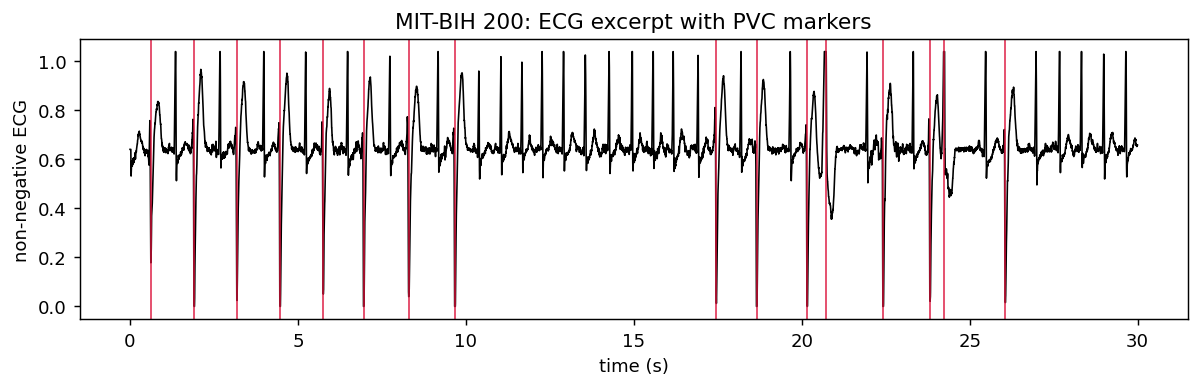

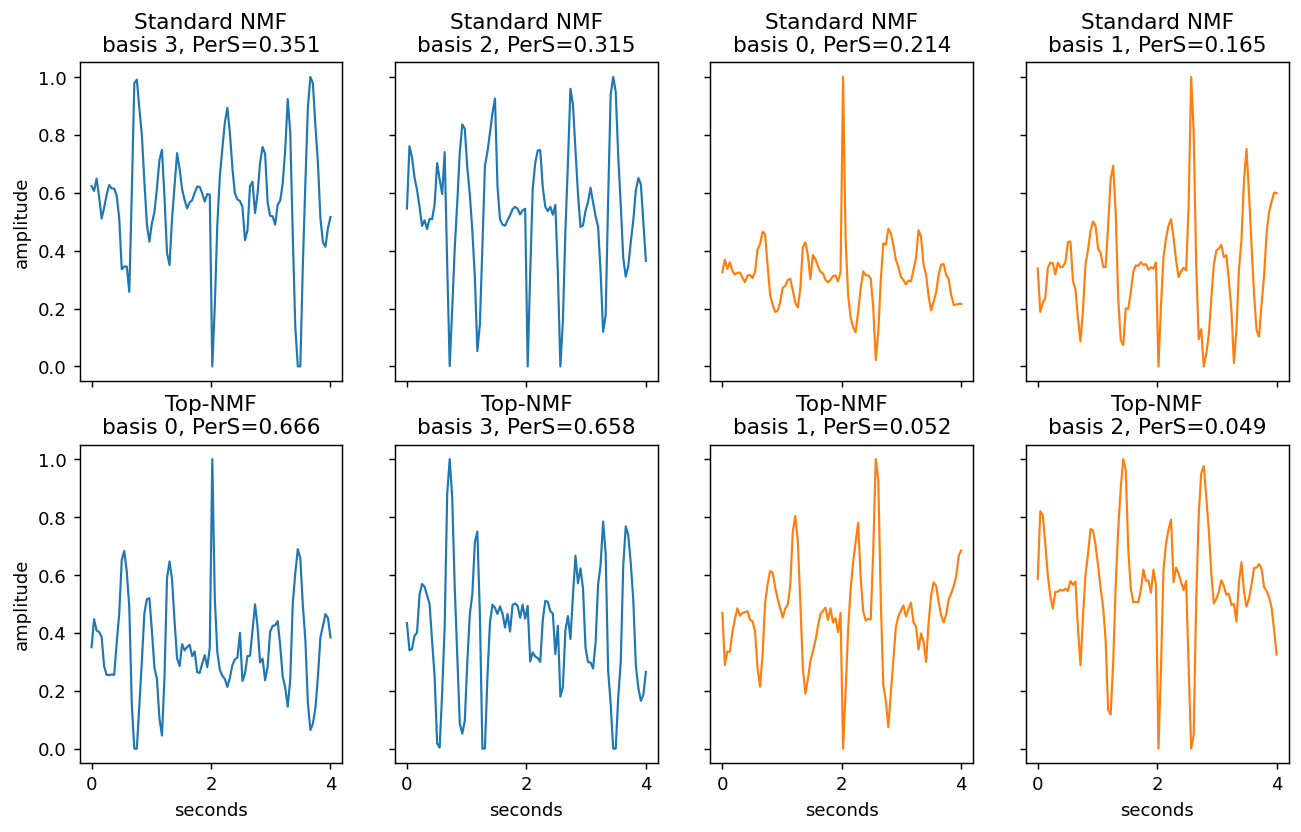

(200,) (200,)


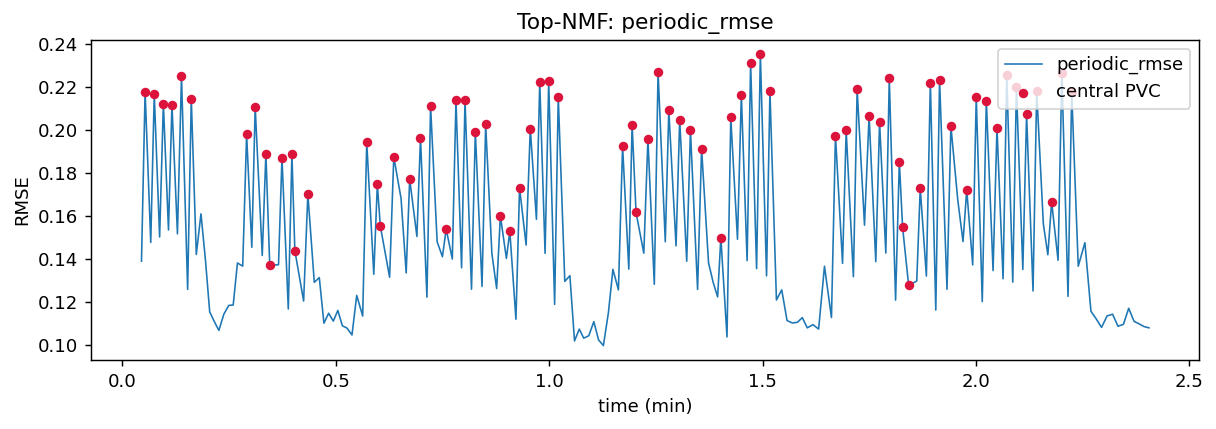

In [13]:
def plot_record_excerpt(record: ECGRecord, processed_signal: np.ndarray, start_sec: float, duration_sec: float) -> None:
    """Plot an ECG excerpt with PVC markers.

    Parameters
    ----------
    record : ECGRecord
        Loaded MIT-BIH record.
    processed_signal : np.ndarray
        Non-negative ECG signal.
    start_sec : float
        Start time in seconds.
    duration_sec : float
        Duration in seconds.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    fs = record.fs
    start = int(round(start_sec * fs))
    stop = min(processed_signal.size, start + int(round(duration_sec * fs)))
    t = np.arange(start, stop) / fs
    fig, ax = plt.subplots(figsize=(11, 2.8))
    ax.plot(t, processed_signal[start:stop], lw=0.9, color="black")
    mask = (record.ann_samples >= start) & (record.ann_samples < stop) & (record.ann_symbols == PVC_SYMBOL)
    for sample in record.ann_samples[mask]:
        ax.axvline(sample / fs, color="crimson", lw=1.0, alpha=0.8)
    ax.set_title(f"MIT-BIH {record.name}: ECG excerpt with PVC markers")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("non-negative ECG")
    fig.savefig(FIGURE_DIR / "MITBIH_ecg_excerpt.pdf")
    show_figure(fig)


def plot_bases(V_by_method: dict[str, np.ndarray], n_periodic: int, embedding_m: int, tau: int) -> None:
    """Plot basis rows sorted by periodicity score.

    Parameters
    ----------
    V_by_method : dict[str, np.ndarray]
        Method name to basis matrix.
    n_periodic : int
        Number of bases treated as periodic.
    embedding_m : int
        TopNMF embedding parameter M.
    tau : int
        Time-delay embedding delay.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    n_methods = len(V_by_method)
    n_components = next(iter(V_by_method.values())).shape[0]
    time = np.linspace(0.0, WINDOW_SEC, next(iter(V_by_method.values())).shape[1])
    fig, axes = plt.subplots(n_methods, n_components, figsize=(12, 3.5 * n_methods), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(n_methods, n_components)
    for row_idx, (method, V) in enumerate(V_by_method.items()):
        Vn = normalise_rows_by_max(V)
        scores = periodicity_scores(Vn, embedding_m, tau)
        order = np.argsort(scores)[::-1]
        periodic_set = set(order[:n_periodic])
        for col_idx, basis_idx in enumerate(order):
            ax = axes[row_idx, col_idx]
            color = "tab:blue" if basis_idx in periodic_set else "tab:orange"
            ax.plot(time, Vn[basis_idx], color=color, lw=1.2)
            ax.set_title(f"{method}\nbasis {basis_idx}, PerS={scores[basis_idx]:.3f}")
            if row_idx == n_methods - 1:
                ax.set_xlabel("seconds")
            if col_idx == 0:
                ax.set_ylabel("amplitude")
    fig.savefig(FIGURE_DIR / "MITBIH_periodic_bases.pdf")
    show_figure(fig)


def plot_anomaly_timeline(meta: pd.DataFrame, scores: pd.DataFrame, method: str, t_max: int=200) -> None:
    """Plot anomaly scores over time with central-PVC markers.

    Parameters
    ----------
    meta : pd.DataFrame
        Window metadata.
    scores : pd.DataFrame
        Per-window score table.
    method : str
        Method name used in the title and filename.

    Returns
    -------
    None
        Displays and saves a figure.
    """
    t = meta["center_sec"].to_numpy()[:t_max] / 60.0
    y = meta["pvc_central"].to_numpy(dtype=bool)[:t_max]
    print(t.shape, y.shape)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(t, scores["periodic_rmse"][:t_max], color="tab:blue", lw=0.9, label="periodic_rmse")
    ax.scatter(t[y], scores[:t_max].loc[y, "periodic_rmse"], s=18, color="crimson", label="central PVC", zorder=3)
    ax.set_title(f"{method}: periodic_rmse")
    ax.set_xlabel("time (min)")
    ax.set_ylabel("RMSE")
    ax.legend(loc="upper right")
    safe_method = method.lower().replace(" ", "_").replace("-", "")
    fig.savefig(FIGURE_DIR / f"MITBIH_{safe_method}_anomaly_timeline.pdf")
    show_figure(fig)


first_pvc = window_meta.loc[window_meta["pvc_central"], "center_sec"].min()
excerpt_start = 0.0 if pd.isna(first_pvc) else max(0.0, float(first_pvc) - 10.0)
plot_record_excerpt(record, processed, start_sec=excerpt_start, duration_sec=30.0)
plot_bases({"Standard NMF": V_std, "Top-NMF": V_top}, PERIODIC_COMPONENTS, EMBEDDING_M, TAU)
plot_anomaly_timeline(window_meta, top_scores, "Top-NMF")

In [14]:
def save_metric_tables(metric_table: pd.DataFrame, detection_table: pd.DataFrame) -> None:
    """Save metric tables for paper drafting.

    Parameters
    ----------
    metric_table : pd.DataFrame
        Factorisation metric table.
    detection_table : pd.DataFrame
        PVC detection metric table.

    Returns
    -------
    None
        Writes CSV files under ``paper/Figures``.
    """
    metric_table.to_csv(FIGURE_DIR / "MITBIH_factorisation_metrics.csv")
    detection_table.to_csv(FIGURE_DIR / "MITBIH_pvc_detection_metrics.csv")


save_metric_tables(metric_table, detection_table)
print(f"Saved figures and tables under: {FIGURE_DIR}")

Saved figures and tables under: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook
